# 07 — Complete End-to-End ANN Training Loop (TensorFlow / Keras)

This is the central engineering notebook. We now train a real `784 → 64 → 10` ANN rather than demonstrating isolated operations.

## The training lifecycle

For each mini-batch:

1. load inputs and labels
2. forward propagation
3. compute loss
4. clear/record gradients correctly
5. backpropagate
6. optimizer update
7. accumulate metrics

At epoch boundaries we evaluate on held-out test data **without training behavior enabled**.

The training loop is shown explicitly rather than delegated to a one-line convenience API so the mechanics remain visible.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


In [2]:
import tensorflow as tf

tf.random.set_seed(SEED)
print('tensorflow version:', tf.__version__)

# 1) tf.data creates an input pipeline with deterministic shuffling and batching.
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(128)
    .prefetch(tf.data.AUTOTUNE)
)

class MNISTMLP(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.hidden = tf.keras.layers.Dense(
            64,
            activation=None,
            kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED),
            name='hidden',
        )
        self.output_layer = tf.keras.layers.Dense(
            10,
            activation=None,
            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
            name='logits',
        )

    def call(self, x, training=False):
        z1 = self.hidden(x)
        a1 = tf.nn.relu(z1)
        logits = self.output_layer(a1)
        return logits

model = MNISTMLP()
# Build the variables once so model.summary() and parameter inspection work.
_ = model(tf.zeros((1, 784), dtype=tf.float32))

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

def train_one_epoch(model, dataset, loss_fn, optimizer):
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for xb, yb in dataset:
        # GradientTape records operations needed for reverse-mode autodiff.
        with tf.GradientTape() as tape:
            logits = model(xb, training=True)
            loss = loss_fn(yb, logits)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        predictions = tf.argmax(logits, axis=1, output_type=tf.int64)
        batch_size = int(xb.shape[0])
        total_loss += float(loss) * batch_size
        total_correct += int(
            tf.reduce_sum(
                tf.cast(predictions == tf.cast(yb, tf.int64), tf.int32)
            )
        )
        total_seen += batch_size

    return total_loss / total_seen, total_correct / total_seen

def evaluate(model, X, y):
    logits = model(X, training=False)
    loss = float(loss_fn(y, logits))
    predictions = tf.argmax(logits, axis=1, output_type=tf.int64)
    accuracy = float(
        tf.reduce_mean(
            tf.cast(predictions == tf.cast(y, tf.int64), tf.float32)
        )
    )
    return loss, accuracy

history = []
for epoch in range(1, 9):
    train_loss, train_acc = train_one_epoch(
        model, train_dataset, loss_fn, optimizer
    )
    test_loss, test_acc = evaluate(model, X_test, y_test)
    history.append((epoch, train_loss, train_acc, test_loss, test_acc))
    print(
        f'epoch={epoch:02d} '
        f'train_loss={train_loss:.4f} '
        f'train_acc={train_acc:.4f} '
        f'test_loss={test_loss:.4f} '
        f'test_acc={test_acc:.4f}'
    )


2026-09-07 12:01:16.945640: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 12:01:16.972746: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow version: 2.18.0


2026-09-07 12:01:18.921985: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=01 train_loss=1.4088 train_acc=0.6116 test_loss=0.7973 test_acc=0.8210


2026-09-07 12:01:19.173959: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

epoch=05 train_loss=0.3078 train_acc=0.9120 test_loss=0.3861 test_acc=0.8820


epoch=06 train_loss=0.2849 train_acc=0.9164 test_loss=0.3593 test_acc=0.8850


epoch=07 train_loss=0.2512 train_acc=0.9296 test_loss=0.3506 test_acc=0.8920


epoch=08 train_loss=0.2302 train_acc=0.9326 test_loss=0.3294 test_acc=0.9020


2026-09-07 12:01:20.611018: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
model.summary()
print('trainable parameters:', model.count_params())
for variable in model.trainable_variables:
    print(f'{variable.name:30s} shape={tuple(variable.shape)}')


Model: "mnistmlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (1, 64)                │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (1, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

trainable parameters: 50890
kernel                         shape=(784, 64)
bias                           shape=(64,)
kernel                         shape=(64, 10)
bias                           shape=(10,)


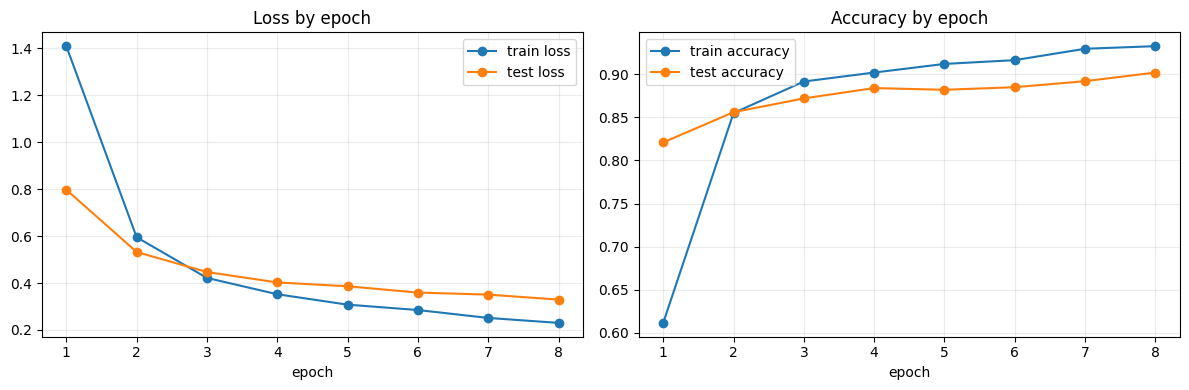

In [4]:
h = np.array(history, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h[:, 0], h[:, 1], marker='o', label='train loss')
axes[0].plot(h[:, 0], h[:, 3], marker='o', label='test loss')
axes[0].set_title('Loss by epoch')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[0].grid(alpha=.25)

axes[1].plot(h[:, 0], h[:, 2], marker='o', label='train accuracy')
axes[1].plot(h[:, 0], h[:, 4], marker='o', label='test accuracy')
axes[1].set_title('Accuracy by epoch')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()


## How to read the curves

- falling training loss means the optimizer is finding parameters that better fit training data
- rising train accuracy with flat test accuracy suggests overfitting or insufficient generalization
- both curves stagnating can indicate optimization, capacity, preprocessing, or gradient-flow problems
- unstable loss can indicate a learning rate that is too high or bad numerical behavior

Business teams ultimately care about decision quality, but these curves are the first diagnostic layer explaining whether the learning system itself behaves correctly.
